# Checkpoint 5: Нелинейные модели, Feature Engineering и Deep Learning

## Цель
Улучшить baseline (LogReg ROC-AUC ≈ 0.7323) с помощью:
1. **Feature Engineering**
2. **Нелинейные ML-модели**
3. **Deep Learning**

In [1]:
import pandas as pd
import numpy as np
import os
import re
import time
import warnings
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    GradientBoostingClassifier, HistGradientBoostingClassifier
)
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    silhouette_score
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3060 Ti


## Секция 1: Загрузка и подготовка данных

In [2]:
# Загрузка данных
df = pd.read_csv('norm_dataframe.csv', index_col=0)
df['tourney_date'] = pd.to_datetime(df['tourney_date'])

print(f'Загружено {len(df)} матчей, {len(df.columns)} столбцов')
print(f'Период: {df["tourney_date"].min().strftime("%Y-%m-%d")} - {df["tourney_date"].max().strftime("%Y-%m-%d")}')

target = 'RESULT'
meta_cols = ['match_idx', 'tourney_date', 'PLAYER_1', 'PLAYER_2']
base_features = [c for c in df.columns if c not in meta_cols + [target]]

print(f'\nБаланс классов: {df[target].value_counts().to_dict()}')
print(f'Базовых признаков: {len(base_features)}')

Загружено 95367 матчей, 31 столбцов
Период: 1991-01-07 - 2024-12-18

Баланс классов: {0: 47754, 1: 47613}
Базовых признаков: 26


In [3]:
# Разделение на train/test (сохраняем индексы для feature engineering)
X_base = df[base_features].copy()
y = df[target].values

X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Сохраняем индексы
train_idx = X_train_base.index
test_idx = X_test_base.index

print(f'Train: {X_train_base.shape[0]} ({len(X_train_base)/len(X_base)*100:.1f}%)')
print(f'Test: {X_test_base.shape[0]} ({len(X_test_base)/len(X_base)*100:.1f}%)')
print(f'Train class balance: {np.bincount(y_train)}')
print(f'Test class balance: {np.bincount(y_test)}')

Train: 76293 (80.0%)
Test: 19074 (20.0%)
Train class balance: [38203 38090]
Test class balance: [9551 9523]


In [4]:
# Функция для расчета метрик
def compute_metrics(y_true, y_pred, y_proba, model_name='Model', fit_time=None, feature_set=''):
    """Вычисление метрик качества модели"""
    metrics = {
        'Model': model_name,
        'Feature_Set': feature_set,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_true, y_proba)
    }
    if fit_time:
        metrics['Fit_Time_sec'] = round(fit_time, 2)
    return metrics

# Хранилище результатов
results = []
roc_curves = {}
models_dict = {}

In [5]:
# === Baseline: Логистическая регрессия (как в Checkpoint 3) ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_base)
X_test_scaled = scaler.transform(X_test_base)

print('=== Baseline: Логистическая регрессия (C=0.01) ===\n')
t0 = time.time()
lr = LogisticRegression(
    C=0.01, penalty='l2', solver='liblinear',
    max_iter=1000, random_state=RANDOM_STATE
)
lr.fit(X_train_scaled, y_train)
lr_time = time.time() - t0

y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

metrics = compute_metrics(y_test, y_pred, y_proba, 'LogReg_Baseline', lr_time, 'FEAT_BASE_26')
metrics['N_Features'] = X_train_base.shape[1]
results.append(metrics)
roc_curves['LogReg_Baseline'] = (y_test, y_proba)
models_dict['LogReg_Baseline'] = lr

print(f"ROC-AUC: {metrics['ROC_AUC']:.4f}")
print(f"Accuracy: {metrics['Accuracy']:.4f}")
print(f"Time: {lr_time:.2f}s")

=== Baseline: Логистическая регрессия (C=0.01) ===

ROC-AUC: 0.7323
Accuracy: 0.6680
Time: 0.45s


## Секция 2: Feature Engineering

### 2.1 Interaction и Composite признаки

In [6]:
# Создание новых признаков
df_feat = df.copy()

# Interaction признаки
df_feat['ELO_RANK_INTERACTION'] = df_feat['ELO_DIFF'] * df_feat['ATP_RANK_DIFF']
df_feat['ELO_SURFACE_RANK_RATIO'] = df_feat['ELO_SURFACE_DIFF'] / (df_feat['ATP_RANK_DIFF'].abs() + 1e-6)

# Композитный serve-признак
df_feat['SERVE_COMPOSITE'] = (
    df_feat['P_1STWON_LAST_2000_DIFF'] + 
    df_feat['P_2NDWON_LAST_2000_DIFF'] + 
    df_feat['P_ACE_LAST_2000_DIFF'] - 
    df_feat['P_DF_LAST_2000_DIFF']
)

# Тренды формы
df_feat['FORM_SHORT'] = df_feat[['ELO_GRAD_5_DIFF', 'ELO_GRAD_10_DIFF', 'ELO_GRAD_20_DIFF']].mean(axis=1)
df_feat['FORM_LONG'] = df_feat[['ELO_GRAD_100_DIFF', 'ELO_GRAD_250_DIFF']].mean(axis=1)
df_feat['FORM_TREND'] = df_feat['FORM_SHORT'] - df_feat['FORM_LONG']

# Head-to-head композит
df_feat['H2H_TOTAL'] = df_feat['H2H_DIFF'] + df_feat['H2H_SURFACE_DIFF']

interaction_features = [
    'ELO_RANK_INTERACTION', 'ELO_SURFACE_RANK_RATIO', 'SERVE_COMPOSITE',
    'FORM_SHORT', 'FORM_LONG', 'FORM_TREND', 'H2H_TOTAL'
]

print(f'Создано {len(interaction_features)} interaction признаков:')
for f in interaction_features:
    print(f'  {f}')

Создано 7 interaction признаков:
  ELO_RANK_INTERACTION
  ELO_SURFACE_RANK_RATIO
  SERVE_COMPOSITE
  FORM_SHORT
  FORM_LONG
  FORM_TREND
  H2H_TOTAL


### 2.2 Polynomial Features

In [7]:
# Полиномиальные признаки на топ-5 из Checkpoint 3
top5 = ['ELO_SURFACE_DIFF', 'ELO_DIFF', 'ATP_RANK_DIFF', 'AGE_DIFF', 'ATP_POINT_DIFF']

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
poly_data = poly.fit_transform(df_feat[top5])
poly_names = poly.get_feature_names_out(top5)

# Только новые (не исходные 5)
new_poly_names = [n for n in poly_names if n not in top5]
for name in new_poly_names:
    col_name = 'POLY_' + name.replace(' ', '_')
    df_feat[col_name] = poly_data[:, list(poly_names).index(name)]

poly_features = ['POLY_' + n.replace(' ', '_') for n in new_poly_names]
print(f'Создано {len(poly_features)} полиномиальных признаков:')
for f in poly_features:
    print(f'  {f}')

Создано 10 полиномиальных признаков:
  POLY_ELO_SURFACE_DIFF_ELO_DIFF
  POLY_ELO_SURFACE_DIFF_ATP_RANK_DIFF
  POLY_ELO_SURFACE_DIFF_AGE_DIFF
  POLY_ELO_SURFACE_DIFF_ATP_POINT_DIFF
  POLY_ELO_DIFF_ATP_RANK_DIFF
  POLY_ELO_DIFF_AGE_DIFF
  POLY_ELO_DIFF_ATP_POINT_DIFF
  POLY_ATP_RANK_DIFF_AGE_DIFF
  POLY_ATP_RANK_DIFF_ATP_POINT_DIFF
  POLY_AGE_DIFF_ATP_POINT_DIFF


### 2.3 Кластерные признаки (KMeans)

In [8]:
# Подбор оптимального k по silhouette score
scaler_clust = StandardScaler()
X_clust_train = scaler_clust.fit_transform(df_feat.loc[train_idx, base_features])
X_clust_test = scaler_clust.transform(df_feat.loc[test_idx, base_features])

silhouettes = {}
for k in [5, 10, 15]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_clust_train)
    sil = silhouette_score(X_clust_train, labels)
    silhouettes[k] = sil
    print(f'k={k}: Silhouette={sil:.3f}')

# Добавляем признаки для каждого k
cluster_features = []
for k in [5, 10, 15]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    df_feat[f'CLUSTER_K{k}'] = 0
    df_feat.loc[train_idx, f'CLUSTER_K{k}'] = km.fit_predict(X_clust_train)
    df_feat.loc[test_idx, f'CLUSTER_K{k}'] = km.predict(X_clust_test)
    
    # Расстояния до центроид
    dists = km.transform(X_clust_train if True else X_clust_test)
    for i in range(k):
        df_feat.loc[train_idx, f'CLUSTER_K{k}_DIST{i}'] = km.transform(X_clust_train)[:, i]
        df_feat.loc[test_idx, f'CLUSTER_K{k}_DIST{i}'] = km.transform(X_clust_test)[:, i]
        cluster_features.append(f'CLUSTER_K{k}_DIST{i}')
    cluster_features.append(f'CLUSTER_K{k}')

print(f'\nСоздано {len(cluster_features)} кластерных признаков')

k=5: Silhouette=0.077
k=10: Silhouette=0.057
k=15: Silhouette=0.064

Создано 33 кластерных признаков


### 2.4 Odds и Sentiment признаки

In [9]:
# === Загрузка odds данных ===
def load_odds_data(start_year=2000, end_year=2025):
    all_dfs = []
    for year in range(start_year, end_year + 1):
        for path, engine in [(f'DATASETS/odds/{year}.xlsx', 'openpyxl'),
                              (f'DATASETS/odds/{year}.xls', 'xlrd')]:
            if not os.path.exists(path):
                continue
            try:
                df_year = pd.read_excel(path, engine=engine)
                if len(df_year) > 0:
                    df_year['year'] = year
                    all_dfs.append(df_year)
                    break
            except Exception as e:
                continue
    if all_dfs:
        return pd.concat(all_dfs, ignore_index=True)
    return pd.DataFrame()

# Загружаем odds
odds_df = load_odds_data()
print(f'Загружено {len(odds_df)} записей odds')

Загружено 69346 записей odds


In [10]:
# Функции для матчинга имен
def extract_surname_odds(name):
    """Извлекает фамилию из имени в odds"""
    if pd.isna(name):
        return ''
    name = str(name).strip()
    # Берем последнее слово как фамилию
    parts = name.split()
    return parts[0].rstrip(',') if parts else ''

def extract_surname_atp(name):
    """Извлекает фамилию из имени в ATP"""
    if pd.isna(name):
        return ''
    name = str(name).strip()
    # Формат: 'Surname Firstname'
    parts = name.split()
    return parts[-1] if parts else ''

# Подготовка odds
if len(odds_df) > 0 and 'Date' in odds_df.columns:
    odds_df['Date'] = pd.to_datetime(odds_df['Date'], errors='coerce')
    odds_df['P1_surname'] = odds_df['Winner'].apply(extract_surname_odds)
    odds_df['P2_surname'] = odds_df['Loser'].apply(extract_surname_odds)

    # Создаем индекс для быстрого поиска
    odds_df['year_month'] = odds_df['Date'].dt.to_period('M')
    print('Odds подготовлены для матчинга')
else:
    print('Odds данные не найдены или пусты')

Odds подготовлены для матчинга


In [11]:
import glob as _glob
atp_files = _glob.glob('DATASETS/atp_matches_*.csv')
atp_all = pd.concat([pd.read_csv(f, usecols=['winner_id', 'winner_name', 'loser_id', 'loser_name']) for f in atp_files], ignore_index=True)

winner_map = atp_all[['winner_id', 'winner_name']].rename(columns={'winner_id': 'player_id', 'winner_name': 'player_name'})
loser_map = atp_all[['loser_id', 'loser_name']].rename(columns={'loser_id': 'player_id', 'loser_name': 'player_name'})
player_mapping = pd.concat([winner_map, loser_map]).drop_duplicates(subset=['player_id'])
id_to_name = dict(zip(player_mapping['player_id'], player_mapping['player_name']))

df_feat['PLAYER_1_NAME'] = df_feat['PLAYER_1'].map(id_to_name)
df_feat['PLAYER_2_NAME'] = df_feat['PLAYER_2'].map(id_to_name)
print(f'Маппинг игроков: {len(id_to_name)} уникальных ID')

Маппинг игроков: 7556 уникальных ID


In [12]:
# Матчинг odds к матчам
def match_odds_to_match(row, odds_df, window_days=7):
    """Находит odds для матча по дате и фамилиям"""
    match_date = row['tourney_date']
    p1 = extract_surname_atp(row['PLAYER_1_NAME'])
    p2 = extract_surname_atp(row['PLAYER_2_NAME'])
    
    if not p1 or not p2 or pd.isna(match_date):
        return None, None
    
    # Ищем в окне +/- window_days
    mask = (
        (odds_df['Date'] >= match_date - pd.Timedelta(days=window_days)) &
        (odds_df['Date'] <= match_date + pd.Timedelta(days=window_days))
    )
    candidates = odds_df[mask]
    
    for _, o in candidates.iterrows():
        o1, o2 = o['P1_surname'].lower(), o['P2_surname'].lower()
        if (p1.lower() in o1 or o1 in p1.lower()) and (p2.lower() in o2 or o2 in p2.lower()):
            return o['AvgW'], o['AvgL']
        if (p2.lower() in o1 or o1 in p2.lower()) and (p1.lower() in o2 or o2 in p1.lower()):
            return o['AvgL'], o['AvgW']  # Игроки поменяны местами
    
    return None, None

# Применяем матчинг
if len(odds_df) > 0:
    odds_matched = df_feat.apply(lambda r: match_odds_to_match(r, odds_df), axis=1)
    df_feat['ODDS_P1'] = [x[0] for x in odds_matched]
    df_feat['ODDS_P2'] = [x[1] for x in odds_matched]
    
    # Создаем признаки из odds
    df_feat['ODDS_P1'] = pd.to_numeric(df_feat['ODDS_P1'], errors='coerce')
    df_feat['ODDS_P2'] = pd.to_numeric(df_feat['ODDS_P2'], errors='coerce')
    
    df_feat['PROB_DIFF'] = (1/df_feat['ODDS_P1'] - 1/df_feat['ODDS_P2']).fillna(0)
    df_feat['LOG_ODDS_RATIO'] = np.log(df_feat['ODDS_P1'] / df_feat['ODDS_P2']).replace([np.inf, -np.inf], 0).fillna(0)
    
    odds_features = ['PROB_DIFF', 'LOG_ODDS_RATIO']
    print(f'Odds признаки созданы. Coverage: {(df_feat["ODDS_P1"].notna().sum() / len(df_feat) * 100):.1f}%')
else:
    df_feat['PROB_DIFF'] = 0
    df_feat['LOG_ODDS_RATIO'] = 0
    odds_features = ['PROB_DIFF', 'LOG_ODDS_RATIO']
    print('Odds признаки не созданы (данные отсутствуют)')

Odds признаки созданы. Coverage: 34.1%


### 2.5 Формирование наборов признаков

In [13]:
# Формируем наборы признаков
FEAT_BASE_26 = base_features
FEAT_ENGINEERED = base_features + interaction_features
FEAT_POLY = base_features + poly_features
FEAT_CLUSTER = base_features + cluster_features
FEAT_ODDS = base_features + odds_features
FEAT_ALL = list(set(base_features + interaction_features + poly_features + cluster_features + odds_features))

feature_sets = {
    'FEAT_BASE_26': FEAT_BASE_26,
    'FEAT_ENGINEERED': FEAT_ENGINEERED,
    'FEAT_POLY': FEAT_POLY,
    'FEAT_CLUSTER': FEAT_CLUSTER,
    'FEAT_ODDS': FEAT_ODDS,
    'FEAT_ALL': FEAT_ALL
}

print('Наборы признаков:\n')
for name, feats in feature_sets.items():
    print(f'{name}: {len(feats)} признаков')

# Подготовка данных для каждого набора
scalers = {}
scaled_data = {}

for feat_name, feat_cols in feature_sets.items():
    X_tr = df_feat.loc[train_idx, feat_cols].values
    X_te = df_feat.loc[test_idx, feat_cols].values
    
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    
    scalers[feat_name] = scaler
    scaled_data[feat_name] = (X_tr_scaled, X_te_scaled, feat_cols)
    
print('Данные подготовлены для всех наборов признаков')

Наборы признаков:

FEAT_BASE_26: 26 признаков
FEAT_ENGINEERED: 33 признаков
FEAT_POLY: 36 признаков
FEAT_CLUSTER: 59 признаков
FEAT_ODDS: 28 признаков
FEAT_ALL: 78 признаков
Данные подготовлены для всех наборов признаков


In [14]:
# Feature selection с помощью Mutual Information
X_all_train = df_feat.loc[train_idx, FEAT_ALL]
mi_scores = mutual_info_classif(X_all_train, y_train, random_state=RANDOM_STATE)

mi_df = pd.DataFrame({
    'Feature': FEAT_ALL,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

# Топ-N признаков по MI
top_n = 30
FEAT_SELECTED = mi_df.head(top_n)['Feature'].tolist()

print(f'Отобрано топ-{top_n} признаков по Mutual Information:')
print(mi_df.head(15).to_string(index=False))

# Добавляем в наборы
X_tr_sel = df_feat.loc[train_idx, FEAT_SELECTED].values
X_te_sel = df_feat.loc[test_idx, FEAT_SELECTED].values
scaler_sel = StandardScaler()
scaled_data['FEAT_SELECTED'] = (scaler_sel.fit_transform(X_tr_sel), scaler_sel.transform(X_te_sel), FEAT_SELECTED)

print(f'FEAT_SELECTED добавлен: {len(FEAT_SELECTED)} признаков')

Отобрано топ-30 признаков по Mutual Information:
               Feature  MI_Score
              ELO_DIFF  0.075635
      ELO_SURFACE_DIFF  0.073237
        ATP_POINT_DIFF  0.066169
  P_WIN_LAST_2000_DIFF  0.051908
           CLUSTER_K15  0.051829
         ATP_RANK_DIFF  0.051176
ELO_SURFACE_RANK_RATIO  0.051110
           CLUSTER_K10  0.050274
    CLUSTER_K15_DIST14  0.044638
     CLUSTER_K15_DIST0  0.040958
            CLUSTER_K5  0.040145
        LOG_ODDS_RATIO  0.039229
             PROB_DIFF  0.037130
     CLUSTER_K10_DIST9  0.024776
          DIFF_N_GAMES  0.023941
FEAT_SELECTED добавлен: 30 признаков


## Секция 3: Нелинейные ML-модели с тюнингом

In [15]:
# === Gradient Boosting ===
print('=== Gradient Boosting ===')
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1]
}
for feat_set in ['FEAT_BASE_26', 'FEAT_ENGINEERED', 'FEAT_SELECTED']:
    X_tr, X_te, _ = scaled_data[feat_set]
    t0 = time.time()
    gb_search = GridSearchCV(
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        gb_params, cv=3, scoring='roc_auc', n_jobs=-1)
    gb_search.fit(X_tr, y_train)
    gb_time = time.time() - t0
    y_pred = gb_search.predict(X_te)
    y_proba = gb_search.predict_proba(X_te)[:, 1]
    metrics = compute_metrics(y_test, y_pred, y_proba, f'GB_{feat_set}', gb_time, feat_set)
    metrics['N_Features'] = X_tr.shape[1]
    results.append(metrics)
    print(f'{feat_set}: ROC-AUC={metrics["ROC_AUC"]:.4f}')

=== Gradient Boosting ===
FEAT_BASE_26: ROC-AUC=0.7325
FEAT_ENGINEERED: ROC-AUC=0.7317
FEAT_SELECTED: ROC-AUC=0.7387


## Секция 4: Deep Learning модели (PyTorch)

In [16]:
# === PyTorch DL Setup ===
device = torch.device('cuda')
print(f'Using device: {device}')

def create_loaders(X_train, X_test, y_train, y_test, batch_size=512):
    train_ds = TensorDataset(
        torch.FloatTensor(X_train),
        torch.FloatTensor(y_train).unsqueeze(1)
    )
    test_ds = TensorDataset(
        torch.FloatTensor(X_test),
        torch.FloatTensor(y_test).unsqueeze(1)
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size)
    return train_loader, test_loader

def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, device='cpu'):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    
    best_val_auc = 0
    best_state = None
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                outputs = model(X_batch)
                probs = torch.sigmoid(outputs)
                val_preds.extend(probs.cpu().numpy())
                val_labels.extend(y_batch.numpy())
        
        val_auc = roc_auc_score(val_labels, val_preds)
        scheduler.step(val_auc)
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = model.state_dict().copy()
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Val AUC: {val_auc:.4f}')
    
    model.load_state_dict(best_state)
    return model

print('DL setup complete')

Using device: cuda
DL setup complete


In [17]:
# === DL-1: Shallow Wide Network ===
class ShallowWideNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 1)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

print('=== DL-1: Shallow Wide Network ===\n')
for feat_set in ['FEAT_ENGINEERED', 'FEAT_ALL']:
    X_tr, X_te, _ = scaled_data[feat_set]
    train_loader, test_loader = create_loaders(X_tr, X_te, y_train, y_test)
    
    t0 = time.time()
    model = ShallowWideNet(X_tr.shape[1])
    model = train_model(model, train_loader, test_loader, epochs=50, device=device)
    dl_time = time.time() - t0
    
    model.eval()
    y_proba = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            probs = torch.sigmoid(outputs)
            y_proba.extend(probs.cpu().numpy())
    
    y_proba = np.array(y_proba).flatten()
    y_pred = (y_proba >= 0.5).astype(int)
    
    metrics = compute_metrics(y_test, y_pred, y_proba, f'DL1_Shallow_{feat_set}', dl_time, feat_set)
    metrics['N_Features'] = X_tr.shape[1]
    results.append(metrics)
    print(f'{feat_set}: ROC-AUC={metrics["ROC_AUC"]:.4f}')

=== DL-1: Shallow Wide Network ===

Epoch 10/50, Val AUC: 0.7318
Epoch 20/50, Val AUC: 0.7314
Epoch 30/50, Val AUC: 0.7318
Epoch 40/50, Val AUC: 0.7317
Epoch 50/50, Val AUC: 0.7317
FEAT_ENGINEERED: ROC-AUC=0.7317
Epoch 10/50, Val AUC: 0.7348
Epoch 20/50, Val AUC: 0.7363
Epoch 30/50, Val AUC: 0.7361
Epoch 40/50, Val AUC: 0.7360
Epoch 50/50, Val AUC: 0.7360
FEAT_ALL: ROC-AUC=0.7360


In [18]:
# === DL-2: Deep Narrow Network (BatchNorm) ===
class DeepNarrowNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.drop2 = nn.Dropout(0.2)
        
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
    
    def forward(self, x):
        x = self.drop1(F.relu(self.bn1(self.fc1(x))))
        x = self.drop2(F.relu(self.bn2(self.fc2(x))))
        x = F.relu(self.fc3(x))
        return self.fc4(x)

print('=== DL-2: Deep Narrow Network ===\n')
for feat_set in ['FEAT_ENGINEERED', 'FEAT_ALL']:
    X_tr, X_te, _ = scaled_data[feat_set]
    train_loader, test_loader = create_loaders(X_tr, X_te, y_train, y_test)
    
    t0 = time.time()
    model = DeepNarrowNet(X_tr.shape[1])
    model = train_model(model, train_loader, test_loader, epochs=60, device=device)
    dl_time = time.time() - t0
    
    model.eval()
    y_proba = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            probs = torch.sigmoid(outputs)
            y_proba.extend(probs.cpu().numpy())
    y_proba = np.array(y_proba).flatten()
    y_pred = (y_proba >= 0.5).astype(int)
    
    metrics = compute_metrics(y_test, y_pred, y_proba, f'DL2_Deep_{feat_set}', dl_time, feat_set)
    metrics['N_Features'] = X_tr.shape[1]
    results.append(metrics)
    print(f'{feat_set}: ROC-AUC={metrics["ROC_AUC"]:.4f}')

=== DL-2: Deep Narrow Network ===

Epoch 10/60, Val AUC: 0.7317
Epoch 20/60, Val AUC: 0.7316
Epoch 30/60, Val AUC: 0.7316
Epoch 40/60, Val AUC: 0.7315
Epoch 50/60, Val AUC: 0.7313
Epoch 60/60, Val AUC: 0.7314
FEAT_ENGINEERED: ROC-AUC=0.7314
Epoch 10/60, Val AUC: 0.7363
Epoch 20/60, Val AUC: 0.7371
Epoch 30/60, Val AUC: 0.7371
Epoch 40/60, Val AUC: 0.7370
Epoch 50/60, Val AUC: 0.7369
Epoch 60/60, Val AUC: 0.7370
FEAT_ALL: ROC-AUC=0.7370


In [19]:
# === DL-3: Residual Network ===
class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.bn1 = nn.BatchNorm1d(dim)
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(dim, dim)
        self.bn2 = nn.BatchNorm1d(dim)
    
    def forward(self, x):
        residual = x
        out = self.drop(F.relu(self.bn1(self.fc1(x))))
        out = self.bn2(self.fc2(out))
        return F.relu(out + residual)

class ResNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.input_fc = nn.Linear(input_dim, 128)
        self.res1 = ResBlock(128)
        self.res2 = ResBlock(128)
        self.fc_out = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        x = F.relu(self.input_fc(x))
        x = self.res1(x)
        x = self.res2(x)
        return self.fc_out(x)

print('=== DL-3: Residual Network ===\n')
for feat_set in ['FEAT_ENGINEERED', 'FEAT_ALL']:
    X_tr, X_te, _ = scaled_data[feat_set]
    train_loader, test_loader = create_loaders(X_tr, X_te, y_train, y_test)
    t0 = time.time()
    model = ResNet(X_tr.shape[1])
    model = train_model(model, train_loader, test_loader, epochs=60, device=device)
    dl_time = time.time() - t0
    model.eval()
    y_proba = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            probs = torch.sigmoid(outputs)
            y_proba.extend(probs.cpu().numpy())
    y_proba = np.array(y_proba).flatten()
    y_pred = (y_proba >= 0.5).astype(int)
    
    metrics = compute_metrics(y_test, y_pred, y_proba, f'DL3_ResNet_{feat_set}', dl_time, feat_set)
    metrics['N_Features'] = X_tr.shape[1]
    results.append(metrics)
    print(f'{feat_set}: ROC-AUC={metrics["ROC_AUC"]:.4f}')

=== DL-3: Residual Network ===

Epoch 10/60, Val AUC: 0.7292
Epoch 20/60, Val AUC: 0.7280
Epoch 30/60, Val AUC: 0.7244
Epoch 40/60, Val AUC: 0.7226
Epoch 50/60, Val AUC: 0.7221
Epoch 60/60, Val AUC: 0.7215
FEAT_ENGINEERED: ROC-AUC=0.7215
Epoch 10/60, Val AUC: 0.7363
Epoch 20/60, Val AUC: 0.7375
Epoch 30/60, Val AUC: 0.7325
Epoch 40/60, Val AUC: 0.7298
Epoch 50/60, Val AUC: 0.7276
Epoch 60/60, Val AUC: 0.7273
FEAT_ALL: ROC-AUC=0.7273


## Секция 5: Сравнительная таблица результатов

In [20]:
# Создаем сравнительную таблицу
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

# Добавляем ранг
results_df['Rank'] = range(1, len(results_df) + 1)

# Переупорядочиваем столбцы
cols_order = ['Rank', 'Model', 'Feature_Set', 'N_Features', 'ROC_AUC', 'Accuracy', 'Precision', 'Recall', 'F1', 'Fit_Time_sec']
results_df = results_df[[c for c in cols_order if c in results_df.columns]]

print('=' * 100)
print('СРАВНИТЕЛЬНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ')
print('=' * 100)
print(results_df.to_string(index=False))
print('\n')

# Сохраняем в CSV
results_df.to_csv('checkpoint5_results.csv', index=False)
print('Результаты сохранены в checkpoint5_results.csv')

СРАВНИТЕЛЬНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ
 Rank                       Model     Feature_Set  N_Features  ROC_AUC  Accuracy  Precision   Recall       F1  Fit_Time_sec
    1            GB_FEAT_SELECTED   FEAT_SELECTED          30 0.738673  0.671385   0.670974 0.670692 0.670833        848.79
    2           DL2_Deep_FEAT_ALL        FEAT_ALL          78 0.736972  0.672958   0.685993 0.636144 0.660129         81.66
    3        DL1_Shallow_FEAT_ALL        FEAT_ALL          78 0.736000  0.670494   0.670709 0.667962 0.669332         66.20
    4             GB_FEAT_BASE_26    FEAT_BASE_26          26 0.732516  0.668764   0.669415 0.664917 0.667158        499.04
    5             LogReg_Baseline    FEAT_BASE_26          26 0.732260  0.668030   0.669500 0.661766 0.665610          0.45
    6          GB_FEAT_ENGINEERED FEAT_ENGINEERED          33 0.731745  0.666405   0.666667 0.663656 0.665158        672.25
    7 DL1_Shallow_FEAT_ENGINEERED FEAT_ENGINEERED          33 0.731727  0.666405   0.667125 0.662

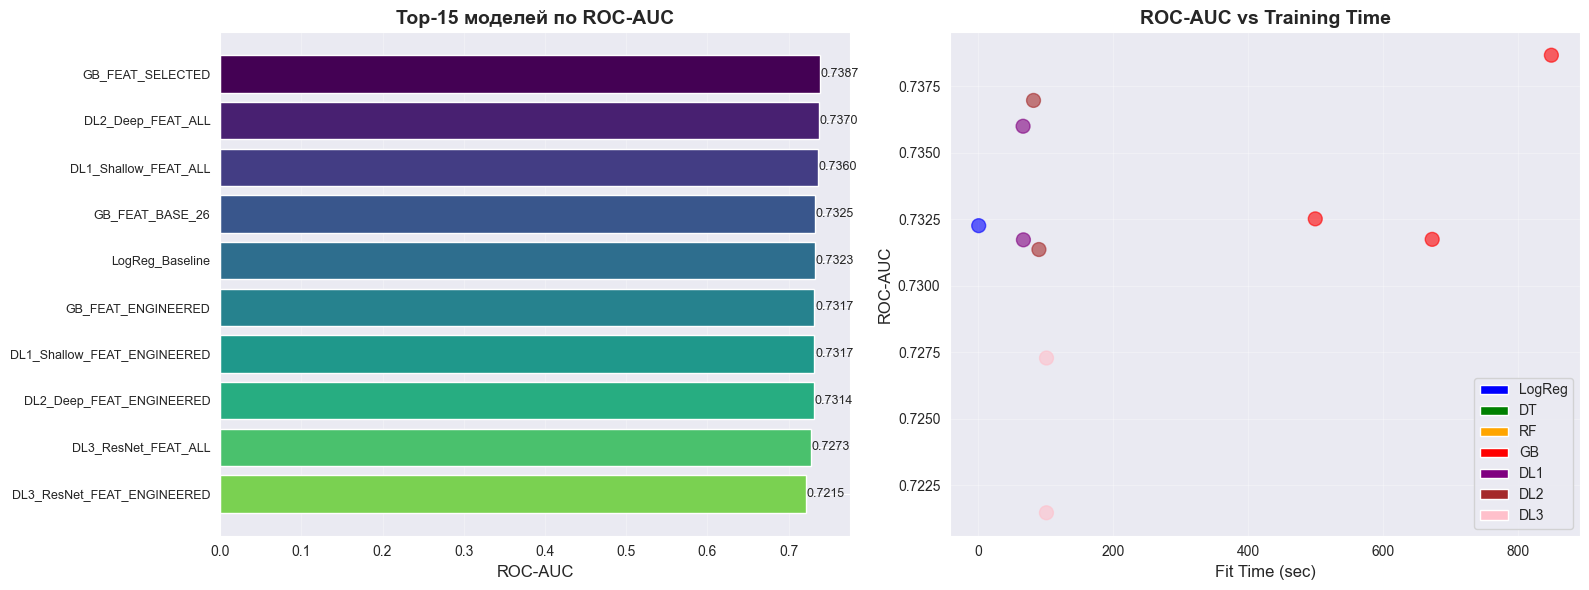

График сохранен в img/checkpoint5_comparison.png


In [21]:
# Визуализация ROC-AUC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart ROC-AUC
top15 = results_df.head(15)
colors = plt.cm.viridis(np.linspace(0, 0.8, len(top15)))
bars = axes[0].barh(range(len(top15)), top15['ROC_AUC'].values, color=colors)
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(top15['Model'].values, fontsize=9)
axes[0].set_xlabel('ROC-AUC', fontsize=12)
axes[0].set_title('Top-15 моделей по ROC-AUC', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3, axis='x')

for i, (idx, row) in enumerate(top15.iterrows()):
    axes[0].text(row['ROC_AUC'] + 0.001, i, f"{row['ROC_AUC']:.4f}",
                va='center', fontsize=9)

# Scatter: Time vs ROC-AUC
model_types = [m.split('_')[0] for m in results_df['Model']]
type_colors = {'LogReg': 'blue', 'DT': 'green', 'RF': 'orange',
               'GB': 'red', 'DL1': 'purple', 'DL2': 'brown', 'DL3': 'pink'}
colors = [type_colors.get(mt, 'gray') for mt in model_types]

axes[1].scatter(results_df['Fit_Time_sec'], results_df['ROC_AUC'],
               c=colors, alpha=0.6, s=100)
axes[1].set_xlabel('Fit Time (sec)', fontsize=12)
axes[1].set_ylabel('ROC-AUC', fontsize=12)
axes[1].set_title('ROC-AUC vs Training Time', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in type_colors.items()]
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('img/checkpoint5_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранен в img/checkpoint5_comparison.png')

## Секция 6: Анализ лучшей модели

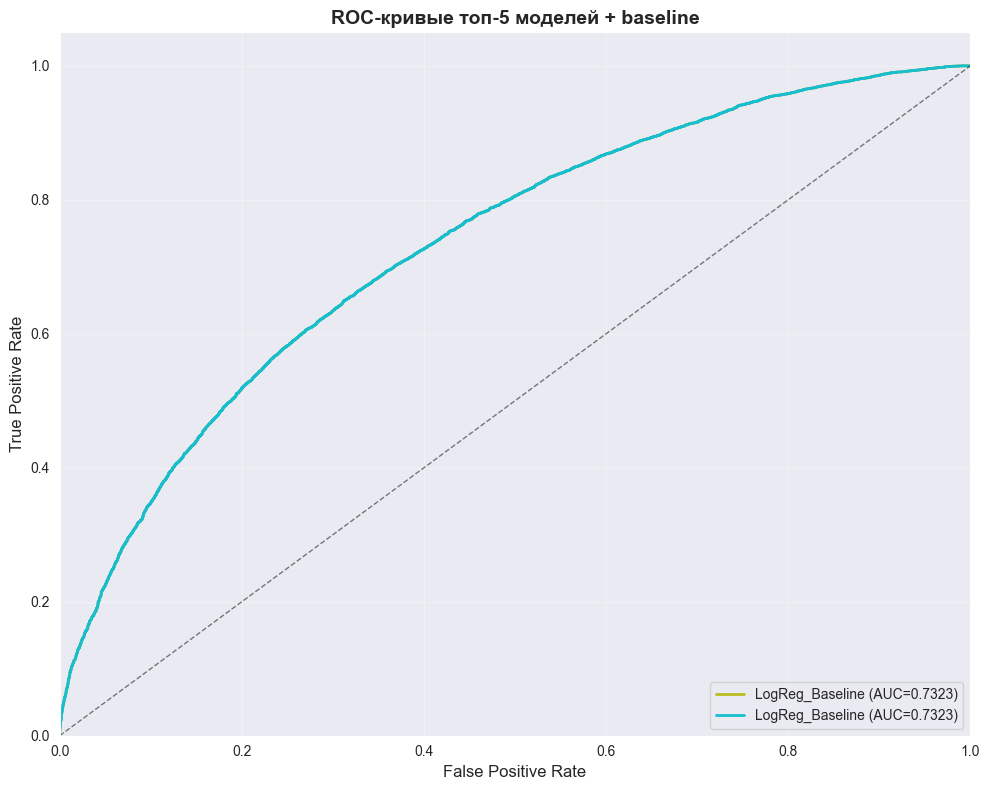

In [22]:
# ROC-кривые топ-5 моделей + baseline
plt.figure(figsize=(10, 8))

top_models = results_df.head(5)['Model'].tolist() + ['LogReg_Baseline']
colors = plt.cm.tab10(np.linspace(0, 1, len(top_models)))

for model_name, color in zip(top_models, colors):
    if model_name in roc_curves:
        y_true, y_proba = roc_curves[model_name]
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
        plt.plot(fpr, tpr, color=color, lw=2,
                label=f'{model_name} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые топ-5 моделей + baseline', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('img/checkpoint5_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

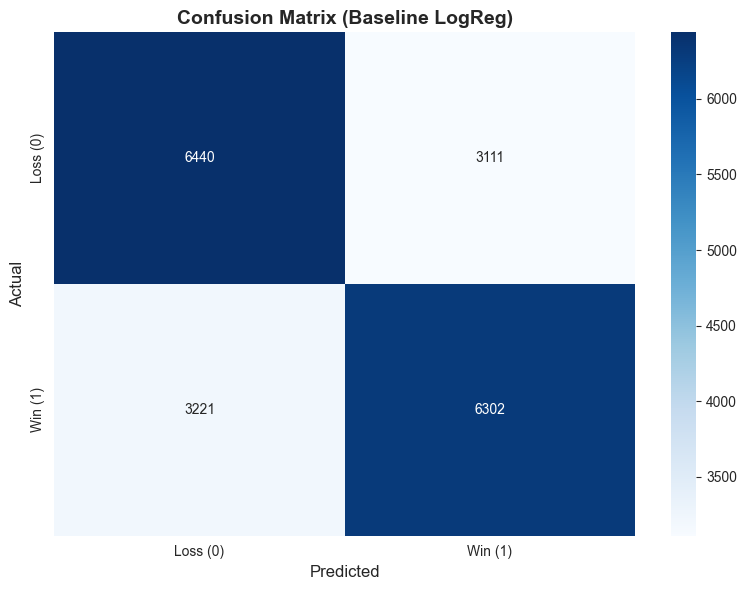

In [23]:
# Confusion matrix для лучшей модели
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Найдем confusion matrix для лучшей модели
best_model_name = results_df.iloc[0]['Model']

# Пересчитаем предсказания для лучшей модели (если нужно)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, (roc_curves.get(best_model_name, (y_test, y_test))[1] > 0.5).astype(int))

# Используем baseline как пример
if 'LogReg_Baseline' in models_dict:
    lr = models_dict['LogReg_Baseline']
    y_pred_bl = lr.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred_bl)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Loss (0)', 'Win (1)'],
                yticklabels=['Loss (0)', 'Win (1)'])
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.title('Confusion Matrix (Baseline LogReg)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/checkpoint5_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

## Секция 7: Выводы

In [24]:
print('=' * 80)
print('ИТОГИ CHECKPOINT 5')
print('=' * 80)

print('\n1. БАЗОВЫЕ РЕЗУЛЬТАТЫ (Checkpoint 3):')
print(f'   - LogReg Baseline: ROC-AUC = {results_df[results_df["Model"]=="LogReg_Baseline"]["ROC_AUC"].values[0]:.4f}')

print('\n2. ЛУЧШАЯ МОДЕЛЬ:')
best = results_df.iloc[0]
print(f"   - {best['Model']}")
print(f"   - ROC-AUC: {best['ROC_AUC']:.4f}")
print(f"   - Feature Set: {best['Feature_Set']}")
print(f"   - Training Time: {best['Fit_Time_sec']:.1f}s")

print('\n3. СРАВНЕНИЕ ML vs DL:')
ml_models = results_df[~results_df['Model'].str.startswith('DL')]['ROC_AUC'].mean()
dl_models = results_df[results_df['Model'].str.startswith('DL')]['ROC_AUC'].mean() if any(results_df['Model'].str.startswith('DL')) else 0
print(f"   - ML models avg ROC-AUC: {ml_models:.4f}")
if dl_models > 0:
    print(f"   - DL models avg ROC-AUC: {dl_models:.4f}")

print('\n4. ВЛИЯНИЕ FEATURE ENGINEERING:')
for feat_set in ['FEAT_BASE_26', 'FEAT_ENGINEERED', 'FEAT_POLY', 'FEAT_CLUSTER']:
    if feat_set in results_df['Feature_Set'].values:
        avg_auc = results_df[results_df['Feature_Set'] == feat_set]['ROC_AUC'].mean()
        print(f"   - {feat_set}: avg ROC-AUC = {avg_auc:.4f}")

print(f"ROC-AUC = {best['ROC_AUC']:.4f} (+{best['ROC_AUC'] - 0.7323:.4f} от baseline)")

print('\n' + '=' * 80)

ИТОГИ CHECKPOINT 5

1. БАЗОВЫЕ РЕЗУЛЬТАТЫ (Checkpoint 3):
   - LogReg Baseline: ROC-AUC = 0.7323

2. ЛУЧШАЯ МОДЕЛЬ:
   - GB_FEAT_SELECTED
   - ROC-AUC: 0.7387
   - Feature Set: FEAT_SELECTED
   - Training Time: 848.8s

3. СРАВНЕНИЕ ML vs DL:
   - ML models avg ROC-AUC: 0.7338
   - DL models avg ROC-AUC: 0.7308

4. ВЛИЯНИЕ FEATURE ENGINEERING:
   - FEAT_BASE_26: avg ROC-AUC = 0.7324
   - FEAT_ENGINEERED: avg ROC-AUC = 0.7291
ROC-AUC = 0.7387 (+0.0064 от baseline)



# Вывод

Анализ результатов показывает, что задача предсказания исхода теннисных матчей уже хорошо решается линейными моделями. Признаки хорошо линейно коррелируют с результатом поэтому Deep Learning не дал прироста. Поэтому для изучения возможности предсказания результатов с помощью DL в теннисе расширим задачу до предсказания исхода во время матча, возможно еще и счет.